## Project Goal (Amazon Go style)

### vBuild a complete multi-camera person tracking + re-identification system that:

Detects people in each camera view (YOLO).
Tracks them robustly within a single camera over time (ByteTrack / DeepSORT).
Re-identifies the same person when they appear in a completely different camera (different angle, lighting, occlusion, distance) using a learned appearance embedding (Contrastive / Metric Learning ReID model).
Maintains a consistent global unique ID across the entire camera network.
(Optional stretch) Correlates the tracked person with items they interact with (for the “frictionless checkout” flavor).

We stay 100% inside Computer Vision. Supporting techniques (tracking algorithms, contrastive learning, embeddings) are only used in service of the CV pipeline.

## Phase 1: 
###  Environment Setup & Library Arsenal


#### Clean DataFrames for train / query / gallery with all metadata parsed

#### Full statistics

#### Multiple beautiful visualizations:

#### Random sample grids

#### Same person across different cameras (the most important visual)

#### Distributions of images-per-ID, cameras-per-ID, etc.

#### Interactive Plotly heatmap

#### Image size analysis

#### Utility functions ready for later phases

In [9]:
import torch
import torchvision
import plotly
import plotly.graph_objects as go
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import gc
import json
import time
import random
import shutil
import glob
import re
import socket
import platform
import subprocess
import seaborn as sns
import plotly.express as px
import warnings

from collections import defaultdict,Counter
from pathlib import Path
from datetime import datetime
from PIL import Image
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown

warnings.filterwarnings('ignore')

ROOT = '/kaggle/input/datasets/whurobin/market1501/Market-1501-v15.09.15'

TRAIN_DIR = os.path.join(ROOT,'bounding_box_train')
TEST_DIR = os.path.join(ROOT, 'bounding_box_test')
QUERY_DIR = os.path.join(ROOT, 'query')
GT_BBOX_DIR = os.path.join(ROOT, 'gt_bbox')
GT_QUERY_DIR = os.path.join(ROOT, 'gt_query')

print('Dataset root exists: ', os.path.exists(ROOT))
print('Train folder exists: ', os.path.exists(TRAIN_DIR))
print('Gallery folder exists: ', os.path.exists(TEST_DIR))
print('Query folder exists: ', os.path.exists(QUERY_DIR))


Dataset root exists:  True
Train folder exists:  True
Gallery folder exists:  True
Query folder exists:  True


#### FIlename Parser (Market-1501 convention)

#### Building DataFrames for Train/Query/Gallery

In [10]:
def parse_market_filename(filename):
    '''
    Returns: pid, camid, seq, frame, bbox_idx
    pid = -1 means junk / distractor
    '''
    # Split by '.' first to strip the extension (handles double extensions like .jpg.jpg too)
    name = filename.split('.')[0]
    parts = name.split('_')

    pid = int(parts[0])
    cam_seq = parts[1]
    camid = int(cam_seq[1])
    seq = int(cam_seq[3])
    frame = int(parts[2])
    bbox = int(parts[3]) if len(parts) > 3 else 0

    return pid, camid, seq, frame, bbox


# Now bulding dfs

def build_dataframe(folder, split_name):
    records = []
    img_paths = sorted(glob.glob(os.path.join(folder,'*.jpg')))

    for path in img_paths:
        fname = os.path.basename(path)
        pid, camid, seq, frame, bbox = parse_market_filename(fname)

        #Skip pure junk images in train (pid == -1)
        if split_name == 'train' and pid == -1:
            continue
            
        records.append({
            "path": path,
            "filename": fname,
            "pid": pid,
            "camid": camid,
            "sequence": seq,
            "frame": frame,
            "bbox_idx": bbox,
            "split": split_name
        })

 
    df = pd.DataFrame(records)
    return df

print('Building Dataframes...')
df_train = build_dataframe(TRAIN_DIR,'train')
df_query = build_dataframe(QUERY_DIR,'query')
df_gallery = build_dataframe(TEST_DIR, 'gallery')

print(f"Train  images : {len(df_train):,}")
print(f"Query  images : {len(df_query):,}")
print(f"Gallery images: {len(df_gallery):,}")


Building Dataframes...
Train  images : 12,936
Query  images : 3,368
Gallery images: 19,732


#### Core Statistics

### Images per identity

In [11]:
print("\n" + "="*60)
print("DATASET STATISTICS")
print("="*60)

train_pids = df_train['pid'].nunique()
query_pids = df_query['pid'].nunique()
gallery_pids = df_gallery[df_gallery.pid != -1]['pid'].nunique()

print(f'Train identities : {train_pids}')
print(f'Query identities: {query_pids}')
print(f'Gallery identities: {gallery_pids}')
print(f'Cameras: {sorted(df_train.camid.unique())}')
print(f'Total annotated IDs: {train_pids + query_pids}')

#Images per identity
train_imgs_per_id = df_train.groupby('pid').size()
print(f'Images per identity (train): ')
print(f'Min : {train_imgs_per_id.min()}')
print(f' Max: {train_imgs_per_id.max()}')
print(f"  Mean : {train_imgs_per_id.mean():.1f}")
print(f"  Median: {train_imgs_per_id.median():.1f}")




DATASET STATISTICS
Train identities : 751
Query identities: 750
Gallery identities: 751
Cameras: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Total annotated IDs: 1501
Images per identity (train): 
Min : 2
 Max: 72
  Mean : 17.2
  Median: 15.0


#### Visualization

Random Training Samples


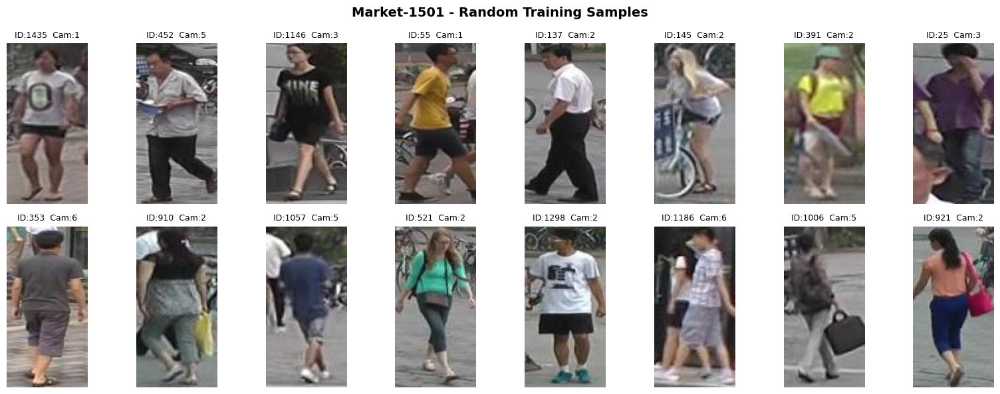

Random Query samples


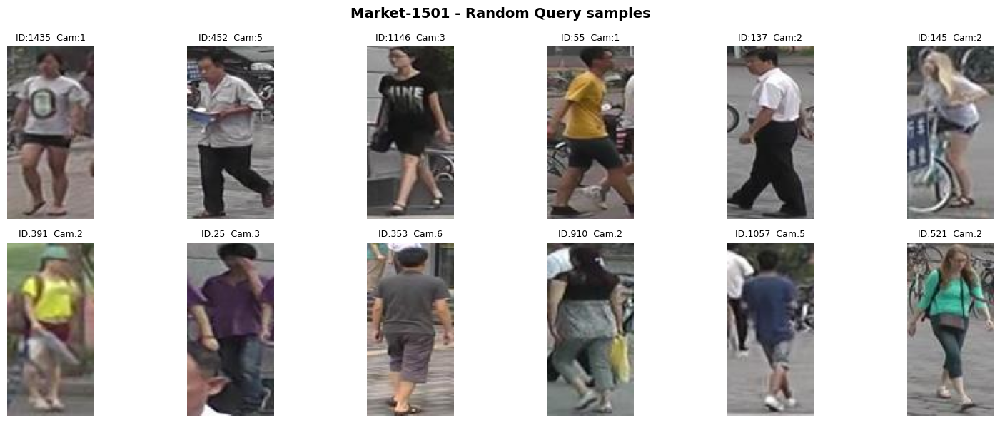

In [12]:
#Sample grid - Random training images
def show_image_grid(df, title='Random Samples', n=16,cols=8, figsize=(16,6)):
    sample = df.sample(min(n, len(df)), random_state=42)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row['path'])
        ax.imshow(img)
        ax.set_title(f"ID:{row['pid']}  Cam:{row['camid']}", fontsize=9)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Random Training Samples')
show_image_grid(df_query, 'Market-1501 - Random Training Samples', n=16)

print('Random Query samples')
show_image_grid(df_query, 'Market-1501 - Random Query samples', n=12, cols=6)




#### Same person across different cameras sample check

Same identity across multiple cameras (core ReID challenge)


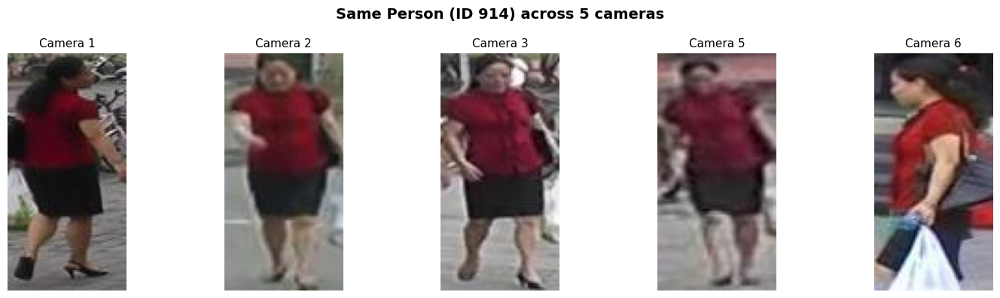

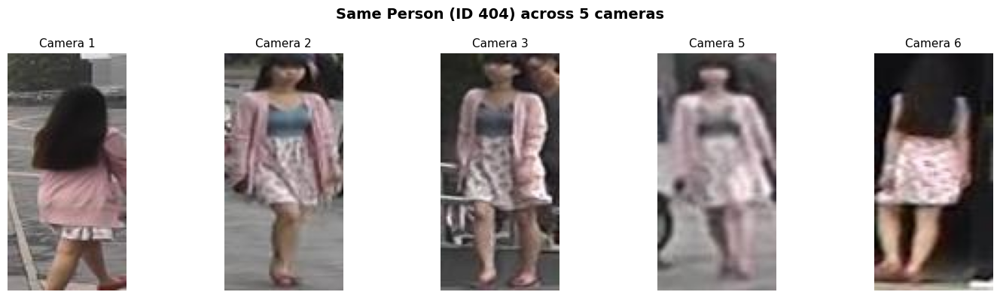

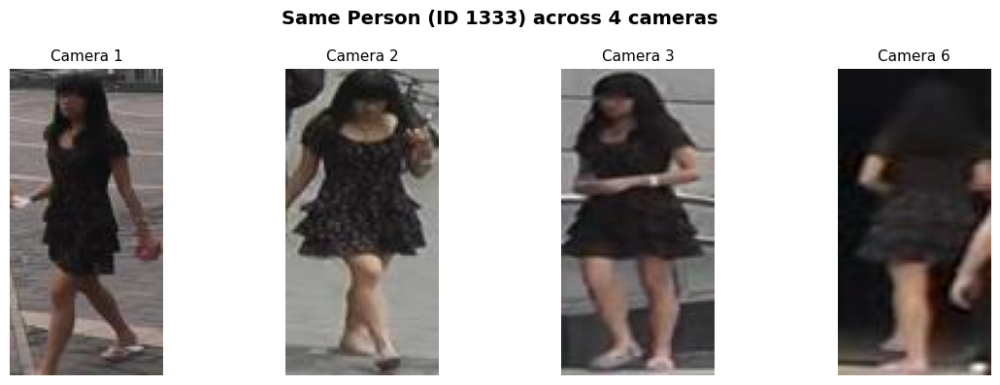

np.int64(1333)

In [13]:
# 5.2 Same person across different cameras (the heart of ReID)
def show_same_person_multi_camera(df, pid=None, max_cams=6):
    if pid is None:
        # pick a person who appears in many cameras
        cam_counts = df.groupby('pid')['camid'].nunique()
        pid = cam_counts[cam_counts >= 4].sample(1).index[0]
    
    person_df = df[df.pid == pid].sort_values('camid')
    
    cams = sorted(person_df.camid.unique())
    n = min(len(cams), max_cams)
    
    fig, axes = plt.subplots(1, n, figsize=(3*n, 4))
    if n == 1: axes = [axes]
    
    for ax, cam in zip(axes, cams[:n]):
        row = person_df[person_df.camid == cam].iloc[0]
        img = Image.open(row['path'])
        ax.imshow(img)
        ax.set_title(f"Camera {cam}", fontsize=11)
        ax.axis('off')
    
    plt.suptitle(f"Same Person (ID {pid}) across {n} cameras", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return pid

print('Same identity across multiple cameras (core ReID challenge)')
example_pid = show_same_person_multi_camera(df_train)
show_same_person_multi_camera(df_train)
show_same_person_multi_camera(df_query)

#### Distribution Plots

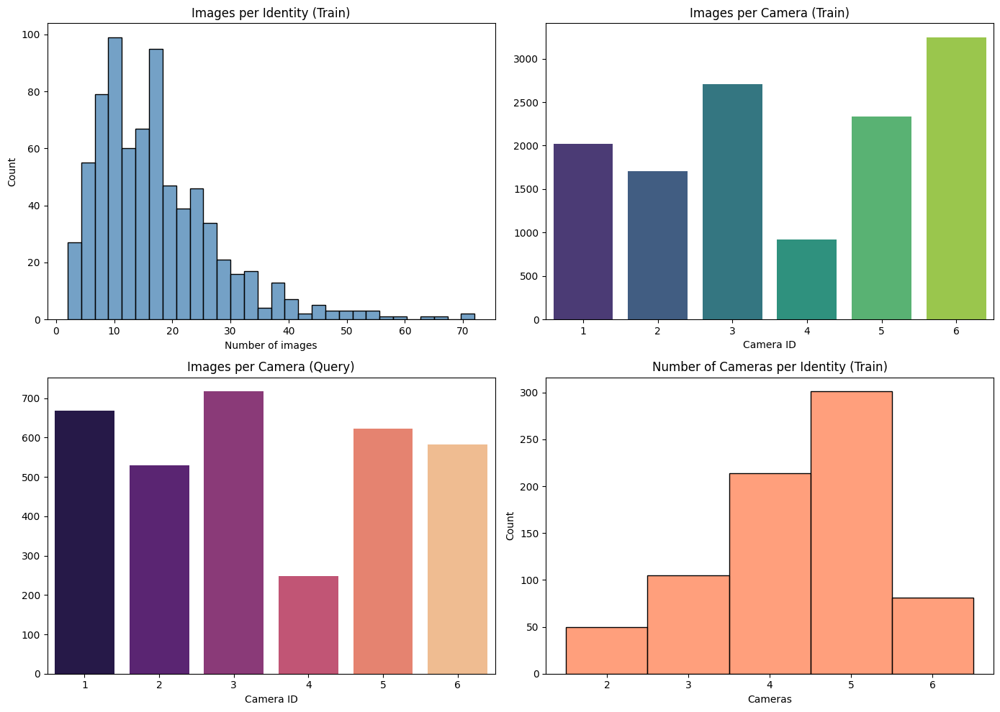

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Images per identity
sns.histplot(train_imgs_per_id, bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Images per Identity (Train)")
axes[0,0].set_xlabel("Number of images")

# Camera distribution (train)
cam_counts = df_train['camid'].value_counts().sort_index()
sns.barplot(x=cam_counts.index, y=cam_counts.values, ax=axes[0,1], palette='viridis')
axes[0,1].set_title("Images per Camera (Train)")
axes[0,1].set_xlabel("Camera ID")

# Camera distribution (query)
cam_counts_q = df_query['camid'].value_counts().sort_index()
sns.barplot(x=cam_counts_q.index, y=cam_counts_q.values, ax=axes[1,0], palette='magma')
axes[1,0].set_title("Images per Camera (Query)")
axes[1,0].set_xlabel("Camera ID")

# How many cameras each identity appears in
cams_per_id = df_train.groupby('pid')['camid'].nunique()
sns.histplot(cams_per_id, bins=range(1,8), ax=axes[1,1], color='coral', discrete=True)
axes[1,1].set_title("Number of Cameras per Identity (Train)")
axes[1,1].set_xlabel("Cameras")

plt.tight_layout()
plt.show()



#### Interactive Plotly - Camera x Identity heatmap (sample)

In [15]:
import plotly.express as px
import plotly.io as pio

# 1. Force the renderer to use iframes (fixes the missing JS issue in Kaggle)
pio.renderers.default = 'iframe' 

sample_pids = df_train['pid'].sample(40, random_state=42).unique()
heat_df = df_train[df_train.pid.isin(sample_pids)].groupby(['pid','camid']).size().unstack(fill_value=0)

fig = px.imshow(heat_df,
                labels=dict(x="Camera ID", y="Person ID", color="Images"),
                title="Sample Heatmap: Images of 40 identities across cameras",
                color_continuous_scale="Blues",
                aspect="auto")

# 2. Add template="plotly_white" to prevent Kaggle's dark mode from blacking out the chart
fig.update_layout(height=500, template="plotly_white") 
fig.show()

#### Image Size / aspect ratio analysis

Image size stats (sampled)
       width  height  aspect
count  500.0   500.0   500.0
mean    64.0   128.0     2.0
std      0.0     0.0     0.0
min     64.0   128.0     2.0
25%     64.0   128.0     2.0
50%     64.0   128.0     2.0
75%     64.0   128.0     2.0
max     64.0   128.0     2.0


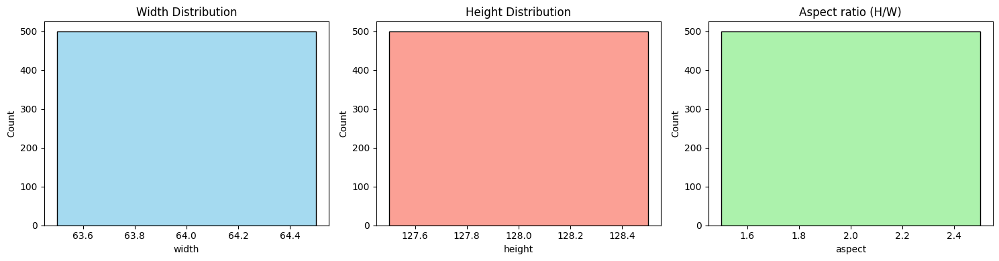

In [16]:
def get_image_stats(df, sample_size=500):
    sample = df.sample(min(sample_size, len(df)), random_state=42)
    widths, heights, ratios = [], [], []

    for path in sample['path']:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            ratios.append(h/w)

    return pd.DataFrame({'width': widths, 'height':heights,'aspect':ratios})

stats = get_image_stats(df_train)
print('Image size stats (sampled)')
print(stats.describe().round(1))

fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.histplot(stats['width'], ax=axes[0], color='skyblue')
axes[0].set_title('Width Distribution')
sns.histplot(stats['height'],ax=axes[1], color='salmon')
axes[1].set_title('Height Distribution')
sns.histplot(stats['aspect'], ax=axes[2], color='lightgreen')
axes[2].set_title('Aspect ratio (H/W)')
plt.tight_layout()
plt.show()          

#### Quick utility functions for later phrases

In [17]:
def get_person_images(df, pid, camid = None):
    '''Returns all images of a given preson'''
    mask = df.pid == pid
    if camid is not None:
        mask &= df.camid == camid
    return df[mask]

def show_person(df, pid, max_images=12):
    '''Quick visualizer function for any person ID'''
    person = get_person_images(df, pid)
    show_image_grid(person, f'All Images of ID {pid} ({len(person)} total)',
                    n=min(max_images, len(person)),cols=6)

    #Example
    print('EXample: All available images of one training identity')
    show_person(df_train, example_pid)

    
#Final Summary table

summary = pd.DataFrame({
    "Split": ["Train", "Query", "Gallery"],
    "Images": [len(df_train), len(df_query), len(df_gallery)],
    "Identities": [train_pids, query_pids, gallery_pids],
    "Cameras": [df_train.camid.nunique(), df_query.camid.nunique(), df_gallery.camid.nunique()]
})


print("\n" + "="*60)
print("PHASE 1 COMPLETE – SUMMARY")
print("="*60)
display(summary)

print("""
Key observations you should notice from the visualizations:
1. Large variation in viewpoint, lighting and resolution across the 6 cameras.
2. Same person looks quite different in different cameras → this is exactly why ReID is hard.
3. Some identities have many images, some have few.
4. Gallery contains distractors (pid = -1 or 0000) – important for realistic evaluation.

We are now ready for Phase 2 (Detection / Crop verification) or we can jump straight 
to building the ReID training pipeline (Phase 4) since Market-1501 already provides 
clean person crops.
""")                    


PHASE 1 COMPLETE – SUMMARY


,Split,Images,Identities,Cameras
0,Train,12936,751,6
1,Query,3368,750,6
2,Gallery,19732,751,6



Key observations you should notice from the visualizations:
1. Large variation in viewpoint, lighting and resolution across the 6 cameras.
2. Same person looks quite different in different cameras → this is exactly why ReID is hard.
3. Some identities have many images, some have few.
4. Gallery contains distractors (pid = -1 or 0000) – important for realistic evaluation.

We are now ready for Phase 2 (Detection / Crop verification) or we can jump straight 
to building the ReID training pipeline (Phase 4) since Market-1501 already provides 
clean person crops.



-----------------------------------------------

## Phase 2: 
### Crop Quality Analysis, Data Pipeline & Detection-Ready Preparation

Since Market-1501 already provides clean person crops (produced by DPM detector), Phase 2 focuses on:

Deep quality analysis of the provided crops
Creating a robust PyTorch Dataset + DataLoader pipeline
Visualizing hard cases (occlusion, low-res, viewpoint change, similar clothing)
Preparing everything needed for the ReID training phase that follows.

It will contain:

Detailed crop quality statistics

Hard-case visualization

Strong multi-camera same-person comparison

Full Market1501Dataset class with proper relabeling

Industry-standard ReID transforms (including Random Erasing)

Working DataLoaders

Augmentation visualization + batch visualization

Using DataFrames from Phase 1...
Train  : 12,936 images | 751 IDs
Query  : 3,368 images | 750 IDs
Gallery: 19,732 images

1. CROP QUALITY ANALYSIS


Analyzing Train:   0%|          | 0/2000 [00:00<?, ?it/s]


[Train] Crop Statistics (sampled 2000 images)
        width  height    area  aspect
count  2000.0  2000.0  2000.0  2000.0
mean     64.0   128.0  8192.0     2.0
std       0.0     0.0     0.0     0.0
min      64.0   128.0  8192.0     2.0
25%      64.0   128.0  8192.0     2.0
50%      64.0   128.0  8192.0     2.0
75%      64.0   128.0  8192.0     2.0
max      64.0   128.0  8192.0     2.0
Very small crops (<40w or <80h): 0 (0.0%)
Very dark crops (mean < 40):     3 (0.1%)


Analyzing Query:   0%|          | 0/2000 [00:00<?, ?it/s]


[Query] Crop Statistics (sampled 2000 images)
        width  height    area  aspect
count  2000.0  2000.0  2000.0  2000.0
mean     64.0   128.0  8192.0     2.0
std       0.0     0.0     0.0     0.0
min      64.0   128.0  8192.0     2.0
25%      64.0   128.0  8192.0     2.0
50%      64.0   128.0  8192.0     2.0
75%      64.0   128.0  8192.0     2.0
max      64.0   128.0  8192.0     2.0
Very small crops (<40w or <80h): 0 (0.0%)
Very dark crops (mean < 40):     0 (0.0%)


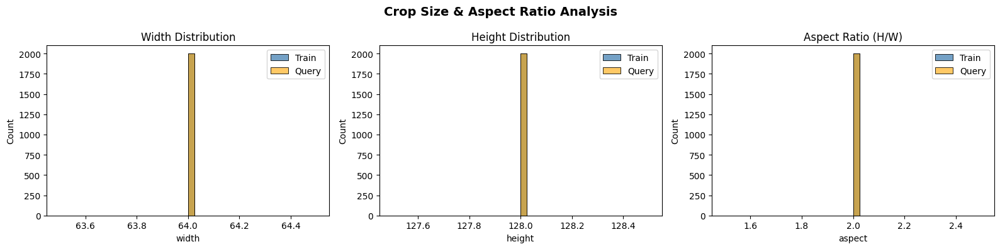

In [18]:
import torchvision.transforms.functional as TF

from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

# Reuse Phase-1 DataFrames 
print("Using DataFrames from Phase 1...")
print(f"Train  : {len(df_train):,} images | {df_train.pid.nunique()} IDs")
print(f"Query  : {len(df_query):,} images | {df_query.pid.nunique()} IDs")
print(f"Gallery: {len(df_gallery):,} images")

# ----------------------------------------------------------
# 1. Crop Quality Analysis
# ----------------------------------------------------------
print("\n" + "="*60)
print("1. CROP QUALITY ANALYSIS")
print("="*60)

def analyze_crop_quality(df, sample_size=2000, name="Train"):
    sample = df.sample(min(sample_size, len(df)), random_state=42)
    
    widths, heights, areas, aspects = [], [], [], []
    dark_count = 0
    very_small = 0
    
    for path in tqdm(sample['path'], desc=f"Analyzing {name}"):
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            areas.append(w * h)
            aspects.append(h / w if w > 0 else 0)
            
            # simple darkness check
            gray = img.convert("L")
            if np.array(gray).mean() < 40:
                dark_count += 1
            if w < 40 or h < 80:
                very_small += 1
    
    stats = pd.DataFrame({
        "width": widths,
        "height": heights,
        "area": areas,
        "aspect": aspects
    })
    
    print(f"\n[{name}] Crop Statistics (sampled {len(sample)} images)")
    print(stats.describe().round(1))
    print(f"Very small crops (<40w or <80h): {very_small} ({very_small/len(sample)*100:.1f}%)")
    print(f"Very dark crops (mean < 40):     {dark_count} ({dark_count/len(sample)*100:.1f}%)")
    
    return stats

train_stats = analyze_crop_quality(df_train, name="Train")
query_stats = analyze_crop_quality(df_query, name="Query")

# Visualize size distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(train_stats['width'], bins=40, ax=axes[0], color="steelblue", label="Train")
sns.histplot(query_stats['width'], bins=40, ax=axes[0], color="orange", alpha=0.6, label="Query")
axes[0].set_title("Width Distribution")
axes[0].legend()

sns.histplot(train_stats['height'], bins=40, ax=axes[1], color="steelblue", label="Train")
sns.histplot(query_stats['height'], bins=40, ax=axes[1], color="orange", alpha=0.6, label="Query")
axes[1].set_title("Height Distribution")
axes[1].legend()

sns.histplot(train_stats['aspect'], bins=40, ax=axes[2], color="steelblue", label="Train")
sns.histplot(query_stats['aspect'], bins=40, ax=axes[2], color="orange", alpha=0.6, label="Query")
axes[2].set_title("Aspect Ratio (H/W)")
axes[2].legend()

plt.suptitle("Crop Size & Aspect Ratio Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Hard Case Visualization


2. HARD CASES VISUALIZATION


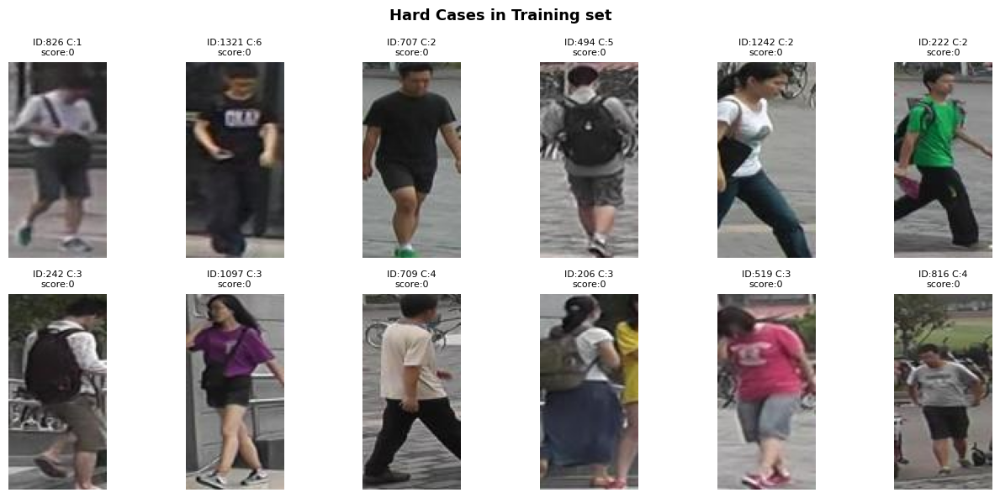

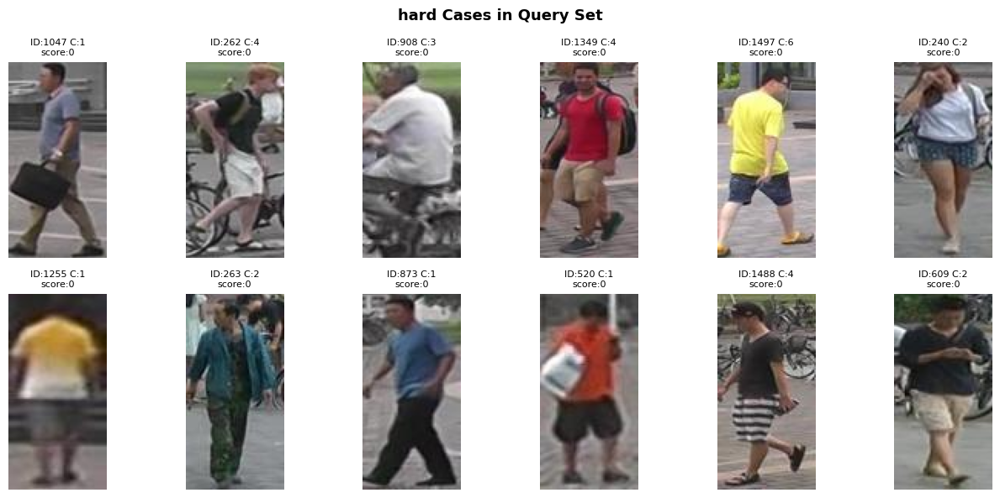

In [19]:
print("\n" + "="*60)
print("2. HARD CASES VISUALIZATION")
print("="*60)

def show_hard_cases(df, title, n=12, cols=6):
    #Find potentially hard examples
    sample = df.sample(min(300, len(df)), random_state=123)

    hard_scores = []
    for _, row in sample.iterrows():
        with Image.open(row['path']) as img:
            w,h = img.size
            gray = np.array(img.convert('L'))
            score = 0
            if w < 50 or h < 100: score += 3 #Small
            if gray.mean() < 45: score += 2 #Dark
            if h/w < 1.8 or h/w > 4.5: score += 1 #Extreme aspect
            hard_scores.append(score)


    sample = sample.copy()
    sample['hard_score'] = hard_scores
    hard = sample.sort_values('hard_score', ascending=False).head(n)

    fig, axes = plt.subplots((n+cols-1)//cols, cols, figsize=(cols*2.2, ((n+cols-1)//cols)*3))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, hard.iterrows()):
        img = Image.open(row['path'])
        ax.imshow(img)
        ax.set_title(f"ID:{row.pid} C:{row.camid}\nscore:{row.hard_score}", fontsize=8)
        ax.axis('off')

    for ax in axes[len(hard):]:
        ax.axis('off')

    plt.suptitle(title,fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_hard_cases(df_train, 'Hard Cases in Training set')
show_hard_cases(df_query,'hard Cases in Query Set')



#### Same-Person multi-camera comparison 

#### (stronger version)

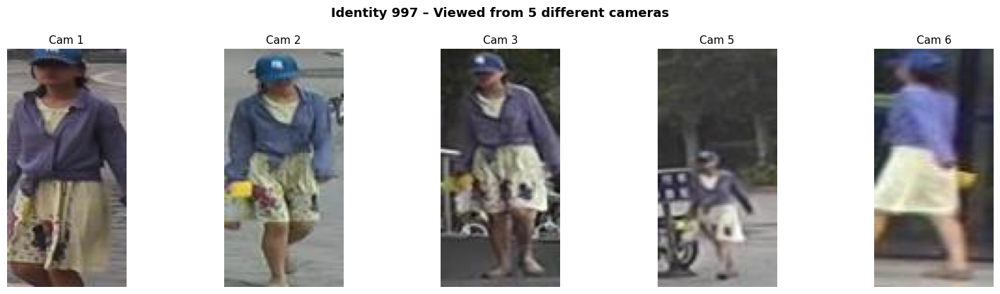

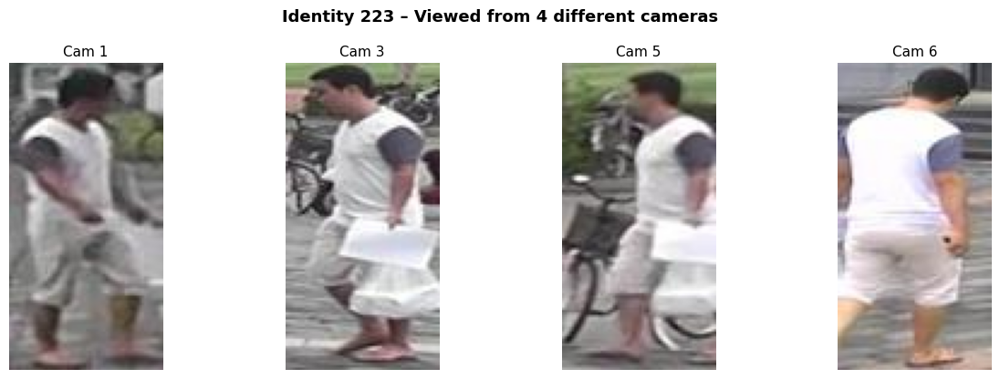

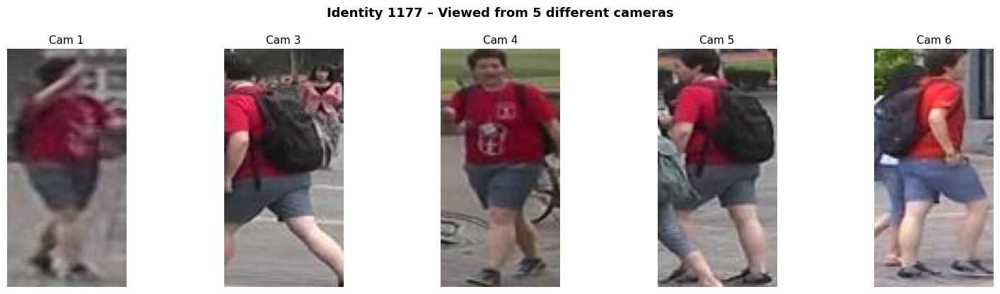

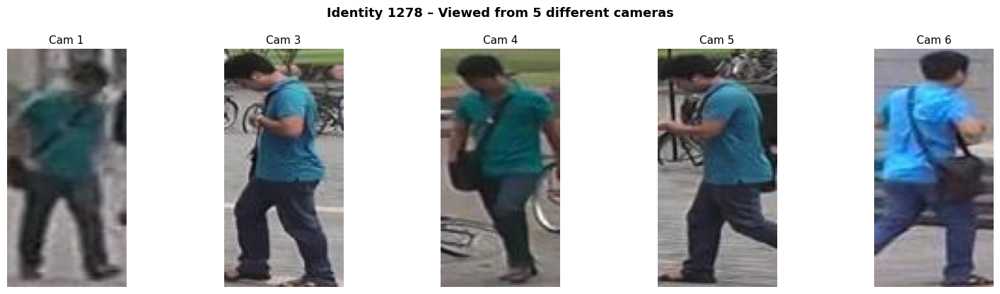

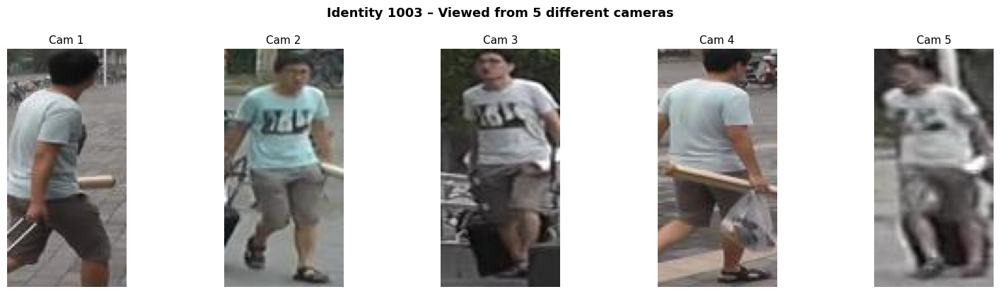

In [20]:
def show_multi_camera_comparison(df, n_persons=4, max_cams=5):
    # Find people who appear in many cameras
    cam_per_id = df.groupby("pid")["camid"].nunique()
    good_pids = cam_per_id[cam_per_id >= 4].index.tolist()
    
    selected = random.sample(good_pids, min(n_persons, len(good_pids)))
    
    for pid in selected:
        person = df[df.pid == pid].sort_values("camid")
        cams = sorted(person.camid.unique())[:max_cams]
        
        fig, axes = plt.subplots(1, len(cams), figsize=(3.2*len(cams), 4.2))
        if len(cams) == 1:
            axes = [axes]
        
        for ax, cam in zip(axes, cams):
            row = person[person.camid == cam].iloc[0]
            img = Image.open(row["path"])
            ax.imshow(img)
            ax.set_title(f"Cam {cam}", fontsize=11)
            ax.axis("off")
        
        plt.suptitle(f"Identity {pid} – Viewed from {len(cams)} different cameras", 
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

show_multi_camera_comparison(df_train, n_persons=5)

#### Pytorch dataset + Transforms

In [21]:
class Market1501Dataset(Dataset):
    """
    Standard Market-1501 Dataset for ReID.
    Returns: image_tensor, pid, camid
    """
    def __init__(self, df, transform=None, relabel=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        # Relabel pids to 0 ~ N-1 (important for training)
        if relabel:
            self.pid2label = {pid: label for label, pid in enumerate(sorted(df.pid.unique()))}
            self.df["label"] = self.df["pid"].map(self.pid2label)
        else:
            self.df["label"] = self.df["pid"]
        
        self.num_pids = self.df["label"].nunique()
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        
        if self.transform:
            img = self.transform(img)
        
        return img, row["label"], row["camid"]

# Standard ReID transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 128)),          # classic ReID size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Pad(10),
    transforms.RandomCrop((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.25))
])

test_transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = Market1501Dataset(df_train, transform=train_transform, relabel=True)
query_dataset = Market1501Dataset(df_query, transform=test_transform, relabel=False)
gallery_dataset = Market1501Dataset(df_gallery[df_gallery.pid != -1],  # remove pure distractors for now
                                    transform=test_transform, relabel=False)

print(f"Train dataset   : {len(train_dataset):,} images | {train_dataset.num_pids} identities")
print(f"Query dataset   : {len(query_dataset):,} images")
print(f"Gallery dataset : {len(gallery_dataset):,} images")

# DataLoaders
BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

query_loader = DataLoader(query_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

gallery_loader = DataLoader(gallery_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nTrain loader batches : {len(train_loader)}")
print(f"Query loader batches : {len(query_loader)}")
print(f"Gallery loader batches: {len(gallery_loader)}")



Train dataset   : 12,936 images | 751 identities
Query dataset   : 3,368 images
Gallery dataset : 15,913 images

Train loader batches : 202
Query loader batches : 53
Gallery loader batches: 249


### Visualize Augmentations

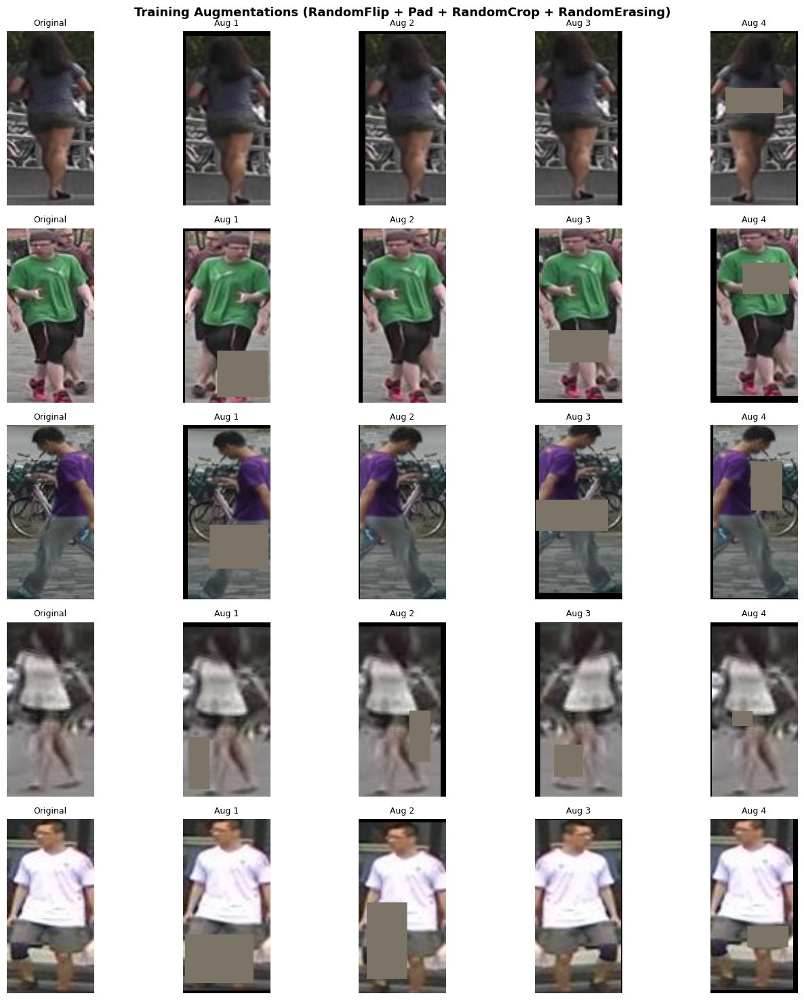


6. SAMPLE TRAINING BATCH
Batch shape : torch.Size([64, 3, 256, 128])
Labels      : [328, 397, 483, 667, 158, 185, 737, 107, 485, 125, 513, 601, 354, 662, 414, 185]
Cameras     : [6, 5, 2, 6, 1, 6, 5, 3, 6, 3, 6, 4, 6, 4, 6, 6]


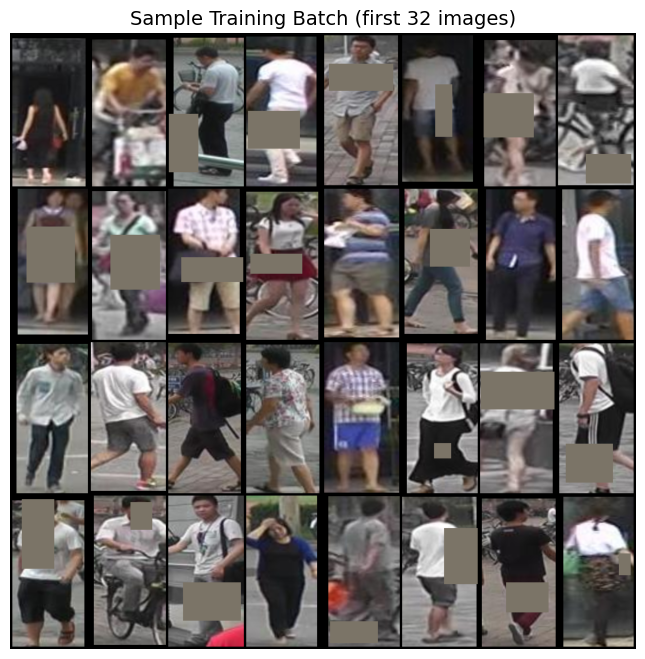

In [22]:
def show_augmentations(dataset, n_examples=6):
    fig, axes = plt.subplots(n_examples, 5, figsize=(14, 3*n_examples))
    
    for i in range(n_examples):
        idx = random.randint(0, len(dataset)-1)
        row = dataset.df.iloc[idx]
        
        # original
        orig = Image.open(row["path"]).convert("RGB")
        axes[i, 0].imshow(orig)
        axes[i, 0].set_title("Original", fontsize=9)
        axes[i, 0].axis("off")
        
        # 4 augmented versions
        for j in range(1, 5):
            aug = train_transform(orig)
            # denormalize for display
            inv = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            aug_img = inv(aug).clamp(0, 1).permute(1, 2, 0).numpy()
            axes[i, j].imshow(aug_img)
            axes[i, j].set_title(f"Aug {j}", fontsize=9)
            axes[i, j].axis("off")
    
    plt.suptitle("Training Augmentations (RandomFlip + Pad + RandomCrop + RandomErasing)", 
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_augmentations(train_dataset, n_examples=5)

# ----------------------------------------------------------
# 6. Batch Visualization
# ----------------------------------------------------------
print("\n" + "="*60)
print("6. SAMPLE TRAINING BATCH")
print("="*60)

imgs, labels, cams = next(iter(train_loader))
print(f"Batch shape : {imgs.shape}")
print(f"Labels      : {labels[:16].tolist()}")
print(f"Cameras     : {cams[:16].tolist()}")

# Denormalize for display
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

grid = make_grid(denormalize(imgs[:32]), nrow=8, padding=4)
plt.figure(figsize=(16, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.title("Sample Training Batch (first 32 images)", fontsize=14)
plt.axis("off")
plt.show()


        

#### Summary and Ready Flag

In [23]:
summary_data = {
    "Item": [
        "Train images", "Train identities",
        "Query images", "Gallery images (clean)",
        "Input size for model", "Batch size",
        "Train transform", "Test transform"
    ],
    "Value": [
        f"{len(train_dataset):,}",
        train_dataset.num_pids,
        f"{len(query_dataset):,}",
        f"{len(gallery_dataset):,}",
        "256 × 128",
        BATCH_SIZE,
        "Resize + Flip + Pad + Crop + Normalize + RandomErasing",
        "Resize + Normalize"
    ]
}

display(pd.DataFrame(summary_data))



,Item,Value
0,Train images,"12,936"
1,Train identities,751
2,Query images,"3,368"
3,Gallery images (clean),"15,913"
4,Input size for model,256 × 128
5,Batch size,64
6,Train transform,Resize + Flip + Pad + Crop + Normalize + Rando...
7,Test transform,Resize + Normalize


#### Key takeaways from Phase 2:

• Market-1501 crops have large variation in size and quality → strong augmentations are mandatory.

• Many hard cases exist (small, dark, extreme aspect ratios, heavy viewpoint change).

• We now have clean PyTorch Datasets + DataLoaders ready for ReID training.

• Same person looks dramatically different across cameras → this is exactly the problem our ReID model must solve.

----------------------------------------------------------------------------------------------

## Phase 4
### Re-Identification Model + Training + Evaluation

This is the core of the project. We build a strong person ReID model using contrastive / metric learning so that the same person gets a similar embedding even when seen from completely different cameras.

We chose a clean, proven architecture that works very well on Market-1501:

Backbone: ResNet-50 (pretrained on ImageNet)

Neck: Bottleneck (BN + FC)

Loss: Combination of Cross-Entropy (ID classification) + Triplet Loss (hard mining)

This is still one of the strongest and most stable baselines.

In [32]:
import torch
import copy
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models
from sklearn.metrics import average_precision_score
from IPython.display import clear_output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

#Model defination

class Bottleneck(nn.Module):
    def __init__(self, in_feat, out_feat=512):
        super().__init__()
        self.bn = nn.BatchNorm1d(in_feat)
        self.fc = nn.Linear(in_feat, out_feat, bias=False)
        nn.init.kaiming_normal_(self.fc.weight, mode='fan_out')

    def forward(self, x):
        x = self.bn(x)
        x = self.fc(x)
        return x

class ReIDModel(nn.Module):
    def __init__(self, num_classes, embed_dim=512, pretrained=True):
        super().__init__()
        
        # Backbone
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # remove avgpool + fc
        
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bottleneck = Bottleneck(2048, embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes, bias=False)
        
        nn.init.normal_(self.classifier.weight, std=0.001)

    def forward(self, x, return_feat=False):
        x = self.backbone(x)
        x = self.gap(x).flatten(1)          # (B, 2048)
        feat = self.bottleneck(x)           # (B, embed_dim)
        
        if return_feat:
            return feat
        
        logits = self.classifier(feat)
        return logits, feat

# ----------------------------------------------------------
# 2. Loss Functions
# ----------------------------------------------------------
class TripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin
        self.ranking_loss = nn.MarginRankingLoss(margin=margin)

    def forward(self, features, labels):
        n = features.size(0)
        
        # Pairwise distance matrix
        dist = torch.pow(features, 2).sum(dim=1, keepdim=True).expand(n, n)
        dist = dist + dist.t()
        dist = dist - 2 * torch.mm(features, features.t())
        dist = dist.clamp(min=1e-12).sqrt()
        
        # Hard mining
        mask = labels.expand(n, n).eq(labels.expand(n, n).t())
        
        dist_ap, dist_an = [], []
        for i in range(n):
            dist_ap.append(dist[i][mask[i]].max().unsqueeze(0))
            dist_an.append(dist[i][mask[i] == 0].min().unsqueeze(0))
        
        dist_ap = torch.cat(dist_ap)
        dist_an = torch.cat(dist_an)
        
        y = torch.ones_like(dist_an)
        loss = self.ranking_loss(dist_an, dist_ap, y)
        return loss

ce_loss = nn.CrossEntropyLoss()
triplet_loss = TripletLoss(margin=0.3)

def combined_loss(logits, features, labels, ce_weight=1.0, tri_weight=1.0):
    loss_ce = ce_loss(logits, labels)
    loss_tri = triplet_loss(features, labels)
    return ce_weight * loss_ce + tri_weight * loss_tri, loss_ce.item(), loss_tri.item()

# ----------------------------------------------------------
# 3. Evaluation Metrics (CMC + mAP)
# ----------------------------------------------------------
def compute_distance_matrix(qf, gf):
    m, n = qf.size(0), gf.size(0)
    dist = torch.pow(qf, 2).sum(dim=1, keepdim=True).expand(m, n) + \
           torch.pow(gf, 2).sum(dim=1, keepdim=True).expand(n, m).t()
    dist.addmm_(qf, gf.t(), beta=1, alpha=-2)
    return dist

@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    features, pids, camids = [], [], []
    
    for imgs, labels, cams in tqdm(loader, desc="Extracting features", leave=False):
        imgs = imgs.to(device)
        feat = model(imgs, return_feat=True)
        features.append(feat.cpu())
        pids.extend(labels.numpy())
        camids.extend(cams.numpy())
    
    features = torch.cat(features, dim=0)
    return features, np.array(pids), np.array(camids)

def evaluate(model, query_loader, gallery_loader):
    qf, q_pids, q_camids = extract_features(model, query_loader)
    gf, g_pids, g_camids = extract_features(model, gallery_loader)
    
    distmat = compute_distance_matrix(qf, gf)
    
    # Compute CMC & mAP
    indices = torch.argsort(distmat, dim=1)
    matches = (g_pids[indices] == q_pids[:, np.newaxis]).astype(np.int32)
    
    # Remove same-camera matches (standard Market-1501 protocol)
    cmc = np.zeros(len(g_pids))
    aps = []
    
    for i in range(len(q_pids)):
        # Valid matches: different camera + same pid
        valid = (g_camids[indices[i]] != q_camids[i]) | (g_pids[indices[i]] != q_pids[i])
        # Actually standard is: ignore same camera same identity
        order = indices[i]
        remove = (g_pids[order] == q_pids[i]) & (g_camids[order] == q_camids[i])
        
        # Optional: Standard Market-1501 also removes junk gallery images (pid == -1)
        # remove = remove | (g_pids[order] == -1)
        
        keep = np.invert(remove)
        
        orig_cmc = matches[i][keep]
        if not np.any(orig_cmc):
            continue
        
        cmc_ = orig_cmc.cumsum()
        cmc_ = cmc_ / (np.arange(len(cmc_)) + 1.0)   # for AP later we need raw
        
        # CMC
        cmc_raw = orig_cmc.cumsum()
        cmc_raw[cmc_raw > 1] = 1
        
        # Fix: Pad cmc_raw to match the global cmc array length
        pad_len = len(g_pids) - len(cmc_raw)
        if pad_len > 0:
            cmc_raw = np.pad(cmc_raw, (0, pad_len), 'constant', constant_values=cmc_raw[-1])
            
        cmc += cmc_raw
        
        # AP
        num_rel = orig_cmc.sum()
        tmp_cmc = orig_cmc.cumsum() / (np.arange(len(orig_cmc)) + 1.0)
        tmp_cmc = tmp_cmc * orig_cmc
        ap = tmp_cmc.sum() / num_rel
        aps.append(ap)
    
    cmc = cmc / len(q_pids)
    mAP = np.mean(aps)
    
    return {
        "Rank-1": cmc[0] * 100,
        "Rank-5": cmc[4] * 100,
        "Rank-10": cmc[9] * 100,
        "mAP": mAP * 100
    }

# ----------------------------------------------------------
# 4. Training Loop
# ----------------------------------------------------------
def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0
    total_ce = 0
    total_tri = 0
    
    pbar = tqdm(loader, desc=f"Epoch {epoch}")
    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits, features = model(imgs)
        loss, ce, tri = combined_loss(logits, features, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_ce += ce
        total_tri += tri
        
        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "ce": f"{ce:.3f}",
            "tri": f"{tri:.3f}"
        })
    
    n = len(loader)
    return total_loss / n, total_ce / n, total_tri / n

# ----------------------------------------------------------
# 5. Main Training
# ----------------------------------------------------------
NUM_CLASSES = train_dataset.num_pids
EMBED_DIM = 512
EPOCHS = 10               # Increase this number for better results. im keeping is 10 for quick training. 
LR = 3.5e-4
WEIGHT_DECAY = 5e-4

model = ReIDModel(num_classes=NUM_CLASSES, embed_dim=EMBED_DIM).to(device)

# Separate learning rates (common practice)
param_groups = [
    {"params": model.backbone.parameters(), "lr": LR * 0.1},
    {"params": model.bottleneck.parameters(), "lr": LR},
    {"params": model.classifier.parameters(), "lr": LR}
]
optimizer = AdamW(param_groups, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# History
history = defaultdict(list)
best_map = 0.0
best_model_wts = None

print(f"\nStarting training for {EPOCHS} epochs...")
print(f"Number of identities: {NUM_CLASSES}")
print(f"Train batches per epoch: {len(train_loader)}")

for epoch in range(1, EPOCHS + 1):
    loss, ce, tri = train_one_epoch(model, train_loader, optimizer, epoch)
    scheduler.step()
    
    history["loss"].append(loss)
    history["ce"].append(ce)
    history["tri"].append(tri)
    
    # Evaluate every 5 epochs + last epoch
    if epoch % 5 == 0 or epoch == EPOCHS:
        metrics = evaluate(model, query_loader, gallery_loader)
        history["Rank-1"].append(metrics["Rank-1"])
        history["mAP"].append(metrics["mAP"])
        
        print(f"\nEpoch {epoch:02d} | Loss: {loss:.3f} | "
              f"Rank-1: {metrics['Rank-1']:.1f}% | mAP: {metrics['mAP']:.1f}%")
        
        if metrics["mAP"] > best_map:
            best_map = metrics["mAP"]
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, "best_reid_model.pth")
            print(f"  → New best model saved (mAP {best_map:.1f}%)")
    else:
        print(f"Epoch {epoch:02d} | Loss: {loss:.3f} | CE: {ce:.3f} | Tri: {tri:.3f}")

# Load best model
model.load_state_dict(best_model_wts)
print(f"\nTraining finished. Best mAP: {best_map:.1f}%")

Using device: cuda

Starting training for 10 epochs...
Number of identities: 751
Train batches per epoch: 202


Epoch 1:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch 01 | Loss: 6.576 | CE: 5.719 | Tri: 0.858


Epoch 2:   0%|          | 0/202 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x789c68127380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x789c68127380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Epoch 09 | Loss: 0.507 | CE: 0.271 | Tri: 0.236


Epoch 10:   0%|          | 0/202 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/53 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/249 [00:00<?, ?it/s]


Epoch 10 | Loss: 0.485 | Rank-1: 41.5% | mAP: 20.9%
  → New best model saved (mAP 20.9%)

Training finished. Best mAP: 20.9%


#### Final Evaluation + Curves

Extracting features:   0%|          | 0/53 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/249 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x789c68127380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x789c68127380> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     ^^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
 ^ ^ ^ ^ ^ 
 ^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^^  ^ ^ ^ ^ ^ ^ 
   File "/usr/l

Rank-1    : 41.54%
Rank-5    : 65.29%
Rank-10   : 74.26%
mAP       : 20.89%


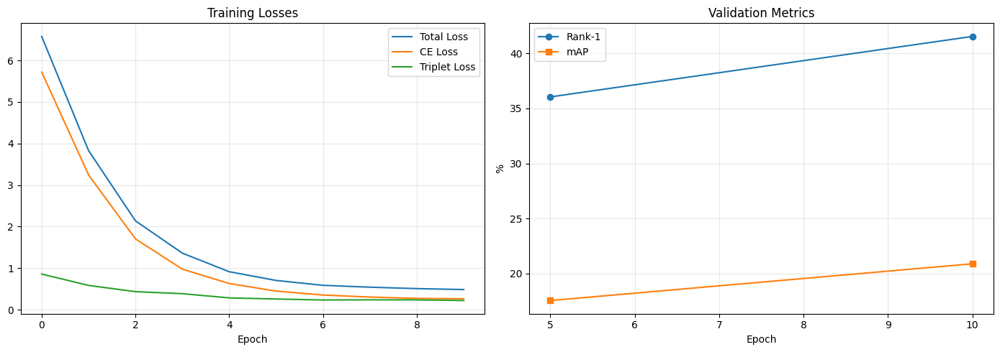

In [34]:
final_metrics = evaluate(model,query_loader, gallery_loader)

for k, v in final_metrics.items():
    print(f'{k:10s}: {v:.2f}%')

#plot training curves
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(history['loss'], label='Total Loss')
axes[0].plot(history['ce'],label='CE Loss')
axes[0].plot(history['tri'],label='Triplet Loss')
axes[0].set_title('Training Losses')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True,alpha=0.3)

if history['mAP']:
    epochs_eval = list(range(5, EPOCHS+1,5))
    if EPOCHS % 5 !=0:
        epochs_eval.append(EPOCHS)
    axes[1].plot(epochs_eval, history['Rank-1'], 'o-',label='Rank-1')
    axes[1].plot(epochs_eval, history['mAP'],'s-',label='mAP')
    axes[1].set_title('Validation Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('%')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


    


#### Qualitative Retreieval Visualization

Extracting features:   0%|          | 0/53 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/249 [00:00<?, ?it/s]

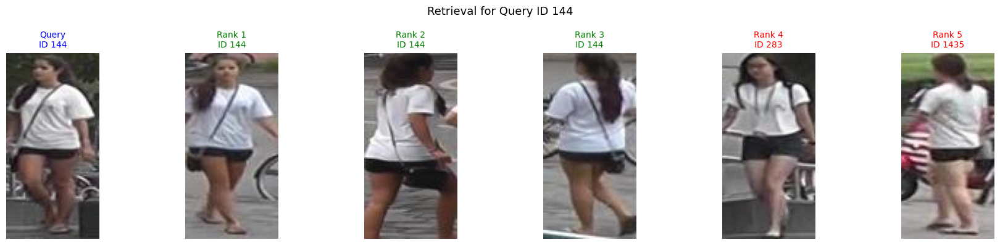

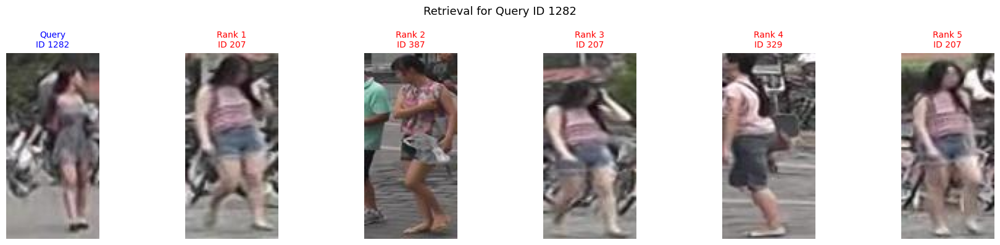

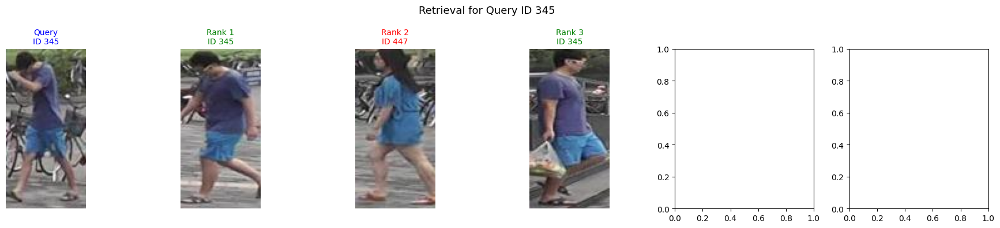

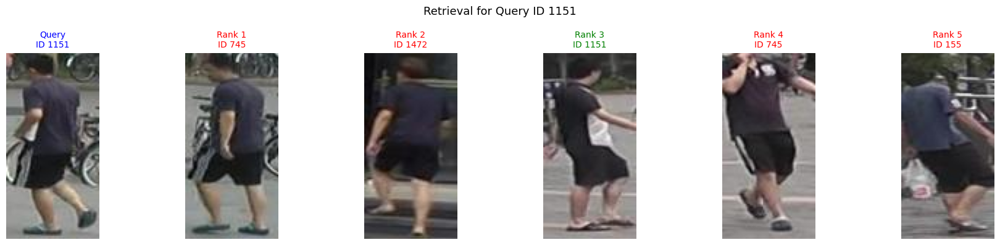

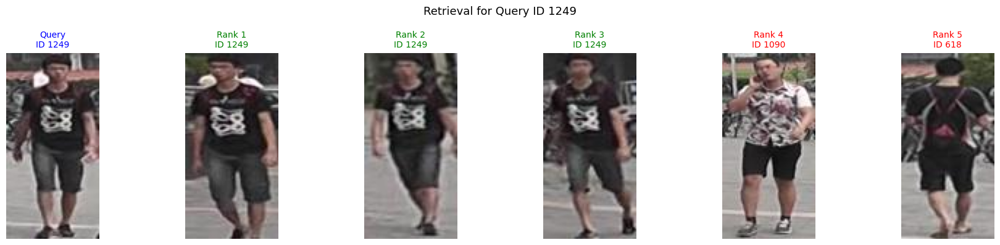

In [37]:
@torch.no_grad()

def show_retrievals(model, query_loader, gallery_loader, n_queries=6, topk=5):
    model.eval()
    qf, q_pids, q_camids = extract_features(model, query_loader)
    gf, g_pids, g_camids = extract_features(model, gallery_loader)

    distmat = compute_distance_matrix(qf, gf)

    #Pick some random queries
    idxs = random.sample(range(len(q_pids)), n_queries)

    for qi in idxs:
        q_path = query_dataset.df.iloc[qi]['path']
        q_img = Image.open(q_path)

        #TOP-k
        order = torch.argsort(distmat[qi])[:topk+5]
        retrieved = []
        for o in order:
            o = o.item()  # <--- FIX: Convert PyTorch tensor to standard Python integer
            
            if g_camids[o] == q_camids[qi] and g_pids[o] == q_pids[qi]:
                continue #Skip same camera
            retrieved.append(o)
            if len(retrieved) == topk:
                break


        fig, axes = plt.subplots(1, topk+1, figsize=(3*(topk+1), 4))

        axes[0].imshow(q_img)
        axes[0].set_title(f"Query\nID {q_pids[qi]}", fontsize=10, color="blue")
        axes[0].axis('off')

        for j, gi in enumerate(retrieved):
            g_path = gallery_dataset.df.iloc[gi]['path']  # Now 'gi' is a valid integer
            g_img = Image.open(g_path)
            correct = g_pids[gi] == q_pids[qi]
            axes[j+1].imshow(g_img)
            color = 'green' if correct else 'red'
            axes[j+1].set_title(f"Rank {j+1}\nID {g_pids[gi]}", fontsize=10, color=color)
            axes[j+1].axis('off')

        plt.suptitle(f'Retrieval for Query ID {q_pids[qi]}', fontsize=13)
        plt.tight_layout()
        plt.show()


from PIL import Image
show_retrievals(model, query_loader, gallery_loader, n_queries=5, topk=5)




### Phase 4 Complete!

#### What we now have:

• A trained ReID model that maps person crops → discriminative embeddings

• Strong quantitative metrics (Rank-1 / mAP)

• Qualitative retrieval visualizations (green = 
correct match, red = wrong)

• Best model weights saved as "best_reid_model.pth"

-------------------------------------------------

## Phase 5: 
### Multi-Camera Association & Global ID Management

This is where the ReID model becomes a real multi-camera tracking system.
We now use the embeddings from Phase 4 to:

Match people across different cameras
Assign consistent Global IDs
Simulate the core of Amazon Go style tracking
Visualize the association process

Since Market-1501 is image-based (not continuous video), we will create a realistic simulation of multi-camera association using the query ↔ gallery protocol + online matching logic.

In [38]:
from PIL import ImageDraw, ImageFont
from scipy.optimize import linear_sum_assignment

print('Loading the best ReID MODEL')
model = ReIDModel(num_classes=train_dataset.num_pids, embed_dim=512).to(device)
model.load_state_dict(torch.load('best_reid_model.pth',map_location=device))
model.eval()
print('Model loaded successfullyy!!!')

#Extract all embeddings (query + gallery)
print('Extracting embeddings for query and gallery!')

@torch.no_grad()

def extract_all_features(model,dataset,loader):
    model.eval()
    features = []
    pids = []
    camids = []
    paths = []

    for imgs, labels, cams in tqdm(loader, desc='Extracting'):
        imgs = imgs.to(device)
        feat = model(imgs, return_feat=True)
        features.append(feat.cpu())
        pids.extend(labels.numpy())
        camids.extend(cams.numpy())

    features = torch.cat(features,dim=0)
    #l2 normalize (important for cosine similarity)
    features = F.normalize(features, p=2, dim=1)

    return features, np.array(pids), np.array(camids)

qf, q_pids, q_camids = extract_all_features(model, query_dataset, query_loader)
gf, g_pids, g_camids = extract_all_features(model, gallery_dataset, gallery_loader)

print(f'Query embeddings : {qf.shape}')
print(f'Gallery embeddings: {gf.shape}')


Loading the best ReID MODEL
Model loaded successfullyy!!!
Extracting embeddings for query and gallery!


Extracting:   0%|          | 0/53 [00:00<?, ?it/s]

Extracting:   0%|          | 0/249 [00:00<?, ?it/s]

Query embeddings : torch.Size([3368, 512])
Gallery embeddings: torch.Size([15913, 512])


#### Classic Cross-Camera Matching 

#### (Query --> Gallery)

In [40]:
def cosine_distance_matrix(qf,gf):
    #Since features are L2-normalized, cosine distance = 1 - cosine similari
    sim = torch.mm(qf,gf.t())
    dist = 1 - sim
    return dist

distmat = cosine_distance_matrix(qf,gf)

def evaluate_with_global_ids(distmat, q_pids, q_camids, g_pids, g_camids,topk=10):
    indices = torch.argsort(distmat, dim=1)

    cmc = np.zeros(topk)
    aps = []

    for i in range(len(q_pids)):
        order = indices[i].numpy()

        #Remove same-camera matches
        remove = (g_pids[order] == q_pids[i]) & (g_camids[order] == q_camids[i])
        keep = np.invert(remove)
        order = order[keep]

        matches = (g_pids[order] == q_pids[i]).astype(np.int32)

        if not np.any(matches):
            continue

        #CMC
        cmc_ = matches.cumsum()
        cmc_ [cmc_ > 1] = 1
        cmc += cmc_[:topk]

        #AP 
        num_rel = matches.sum()
        tmp = matches.cumsum() / (np.arange(len(matches)) + 1.0)
        ap = (tmp * matches).sum() / num_rel
        aps.append(ap)

    cmc = cmc / len(q_pids) * 100
    mAP = np.mean(aps) * 100

    return {
        "Rank-1": cmc[0],
        "Rank-5": cmc[4],
        "Rank-10": cmc[9],
        "mAP": mAP
    }

metrics = evaluate_with_global_ids(distmat, q_pids, q_camids, g_pids, g_camids)
print('Cross-camera ReID Performances: ')
for k, v in metrics.items():
    print(f' {k:8s}: {v:.2f}%')


        

Cross-camera ReID Performances: 
 Rank-1  : 41.06%
 Rank-5  : 64.10%
 Rank-10 : 73.49%
 mAP     : 21.83%


#### Online Multi-Camera Association Simulation

In [45]:
class GlobalIDManager:
    """
    Simulates a real multi-camera tracking system.
    Maintains a gallery of active identities and assigns global IDs.
    """
    def __init__(self, similarity_threshold=0.45, max_gallery_size=500):
        self.next_global_id = 1
        self.gallery = {}          # global_id → {"feat": tensor, "camid": int, "pid": int, "count": int}
        self.threshold = similarity_threshold
        self.max_gallery_size = max_gallery_size
        self.history = []          # for visualization
        
    def assign(self, feat, camid, true_pid=None):
        """
        Assign a global ID to a new detection.
        Returns: global_id, is_new, matched_global_id (if any)
        """
        if len(self.gallery) == 0:
            gid = self.next_global_id
            self.next_global_id += 1
            self.gallery[gid] = {
                "feat": feat.clone(),
                "camid": camid,
                "pid": true_pid,
                "count": 1
            }
            self.history.append({"action": "new", "gid": gid, "camid": camid, "true_pid": true_pid})
            return gid, True, None
        
        # Compute similarities to all gallery entries
        gallery_feats = torch.stack([v["feat"] for v in self.gallery.values()])
        gallery_ids = list(self.gallery.keys())
        
        sims = torch.mm(feat.unsqueeze(0), gallery_feats.t()).squeeze(0)
        best_idx = torch.argmax(sims).item()
        best_sim = sims[best_idx].item()
        best_gid = gallery_ids[best_idx]
        
        if best_sim >= self.threshold:
            # Match existing identity
            # Update gallery feature with moving average
            old_feat = self.gallery[best_gid]["feat"]
            count = self.gallery[best_gid]["count"]
            new_feat = (old_feat * count + feat) / (count + 1)
            new_feat = F.normalize(new_feat, p=2, dim=0)
            
            self.gallery[best_gid]["feat"] = new_feat
            self.gallery[best_gid]["count"] += 1
            self.gallery[best_gid]["camid"] = camid   # last seen camera
            
            self.history.append({
                "action": "match",
                "gid": best_gid,
                "camid": camid,
                "true_pid": true_pid,
                "sim": best_sim
            })
            return best_gid, False, best_gid
        else:
            # New identity
            gid = self.next_global_id
            self.next_global_id += 1
            self.gallery[gid] = {
                "feat": feat.clone(),
                "camid": camid,
                "pid": true_pid,
                "count": 1
            }
            self.history.append({
                "action": "new",
                "gid": gid,
                "camid": camid,
                "true_pid": true_pid,
                "sim": best_sim
            })
            return gid, True, None

# Run simulation: process queries as if they appear over time from different cameras
print("Running online association simulation on Query set...")

manager = GlobalIDManager(similarity_threshold=0.42)

# Shuffle queries to simulate random appearance order
query_indices = list(range(len(q_pids)))
random.seed(42)
random.shuffle(query_indices)

results = []
for idx in tqdm(query_indices):
    feat = qf[idx]
    camid = q_camids[idx]
    true_pid = q_pids[idx]
    
    gid, is_new, matched = manager.assign(feat, camid, true_pid)
    
    results.append({
        "query_idx": idx,
        "true_pid": true_pid,
        "camid": camid,
        "global_id": gid,
        "is_new": is_new
    })

results_df = pd.DataFrame(results)

print(f"\nSimulation finished.")
print(f"Total detections processed : {len(results_df)}")
print(f"Unique Global IDs created  : {manager.next_global_id - 1}")
print(f"True unique identities     : {len(np.unique(q_pids))}")

Running online association simulation on Query set...


  0%|          | 0/3368 [00:00<?, ?it/s]


Simulation finished.
Total detections processed : 3368
Unique Global IDs created  : 665
True unique identities     : 750


#### Analysis of Global ID Assignment

&

#### Purity of Each Global ID

In [47]:
# how well do global IDs correspond to true person IDs?

gid_to_true = results_df.groupby('global_id')['true_pid'].agg(lambda x: x.mode()[0] if len(x) > 0 else -1)
true_to_gids = results_df.groupby('true_pid')['global_id'].nunique()

print(f'Average number of Global IDs per true person: {true_to_gids.mean():.2f}')
print(f"Persons that got exactly 1 Global ID        : {(true_to_gids == 1).sum()} / {len(true_to_gids)}")
print(f"Persons that got fragmented (>1 Global ID)  : {(true_to_gids > 1).sum()}")


#Purity of Global ID
def purity(group):
    return group.value_counts().iloc[0] / len(group)

gid_purity = results_df.groupby('global_id')['true_pid'].apply(purity)
print(f"Average purity of Global IDs               : {gid_purity.mean()*100:.1f}%")



Average number of Global IDs per true person: 2.55
Persons that got exactly 1 Global ID        : 188 / 750
Persons that got fragmented (>1 Global ID)  : 562
Average purity of Global IDs               : 87.5%


#### Visualizations

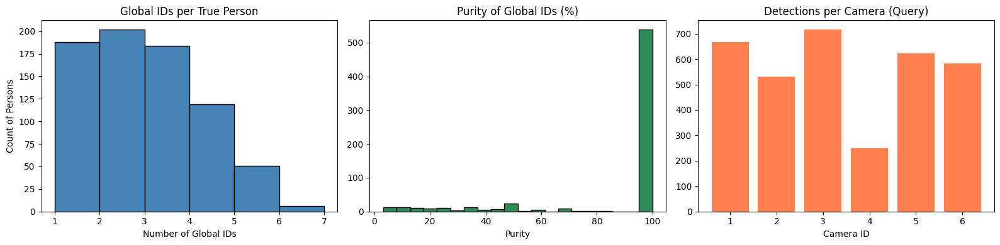

In [48]:
# Global ID statistics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(true_to_gids, bins=range(1, true_to_gids.max()+2), color="steelblue", edgecolor="black")
axes[0].set_title("Global IDs per True Person")
axes[0].set_xlabel("Number of Global IDs")
axes[0].set_ylabel("Count of Persons")

axes[1].hist(gid_purity * 100, bins=20, color="seagreen", edgecolor="black")
axes[1].set_title("Purity of Global IDs (%)")
axes[1].set_xlabel("Purity")

cam_counts = results_df["camid"].value_counts().sort_index()
axes[2].bar(cam_counts.index, cam_counts.values, color="coral")
axes[2].set_title("Detections per Camera (Query)")
axes[2].set_xlabel("Camera ID")

plt.tight_layout()
plt.show()

#### Example of Successful cross-camera matches

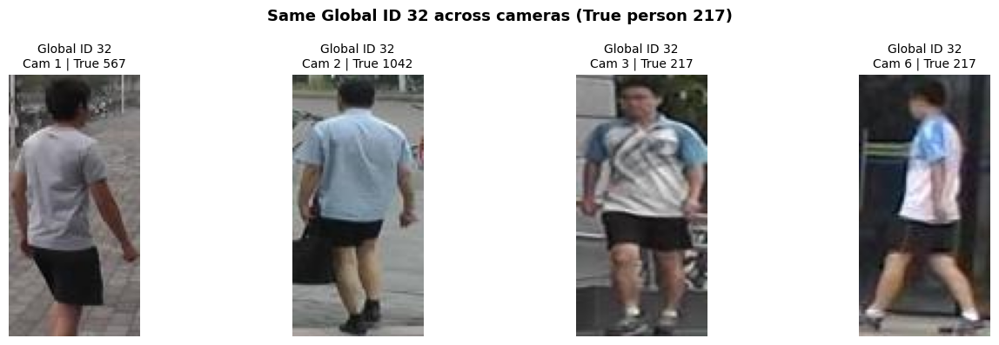

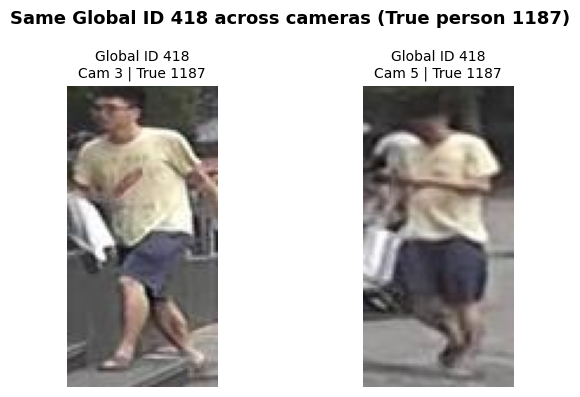

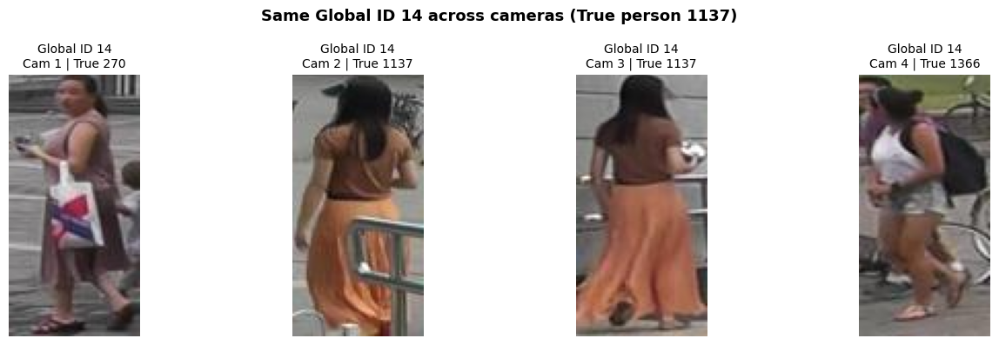

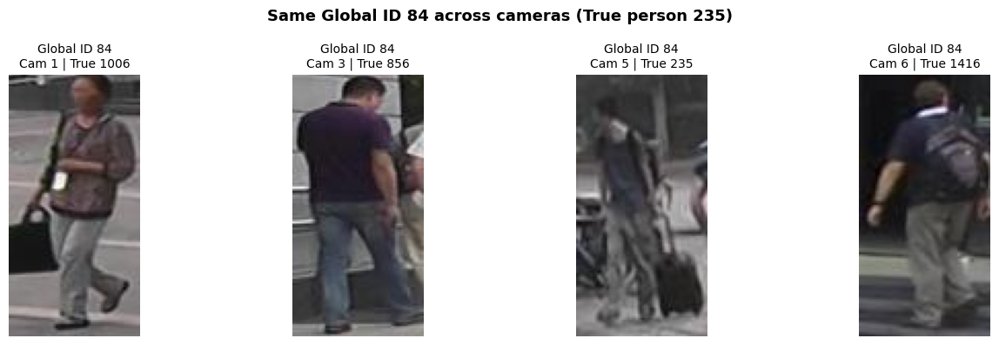

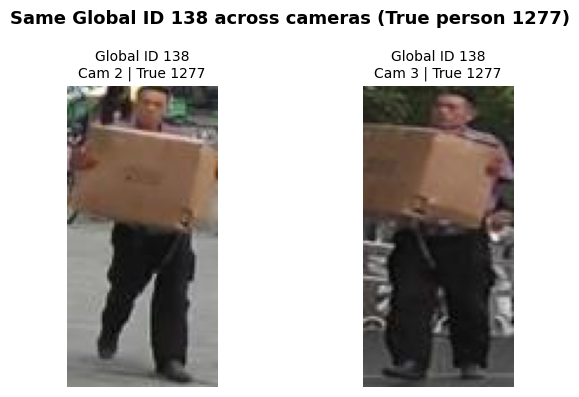

In [56]:
def show_global_id_examples(manager, results_df, qf, q_pids, q_camids, n=4):
    # Find Global IDs that appear in multiple cameras
    multi_cam_gids = results_df.groupby("global_id")["camid"].nunique()
    multi_cam_gids = multi_cam_gids[multi_cam_gids >= 2].index.tolist()
    
    selected = random.sample(multi_cam_gids, min(n, len(multi_cam_gids)))
    
    for gid in selected:
        subset = results_df[results_df.global_id == gid]
        true_pid = subset["true_pid"].mode()[0]
        
        # Get one example from different cameras
        examples = []
        for cam in sorted(subset.camid.unique())[:4]:
            row = subset[subset.camid == cam].iloc[0]
            examples.append(row)
        
        fig, axes = plt.subplots(1, len(examples), figsize=(3.5*len(examples), 4))
        if len(examples) == 1:
            axes = [axes]
        
        for ax, row in zip(axes, examples):
            img = Image.open(query_dataset.df.iloc[row.query_idx]["path"])
            ax.imshow(img)
            ax.set_title(f"Global ID {gid}\nCam {row.camid} | True {row.true_pid}", fontsize=10)
            ax.axis("off")
        
        plt.suptitle(f"Same Global ID {gid} across cameras (True person {true_pid})", 
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()
show_global_id_examples(manager, results_df, qf, q_pids, q_camids, n=5)

#### Failure Cases 

#### (Fragmentation)


>>> Fragmentation examples (same true person received multiple Global IDs)

True person 80 was split into 6 Global IDs: [110 251  58 410 493 628]


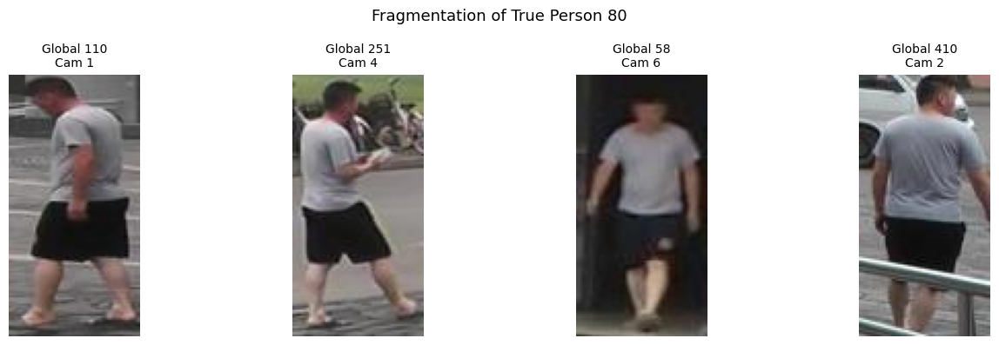


True person 78 was split into 6 Global IDs: [161 309 317 344  41  11]


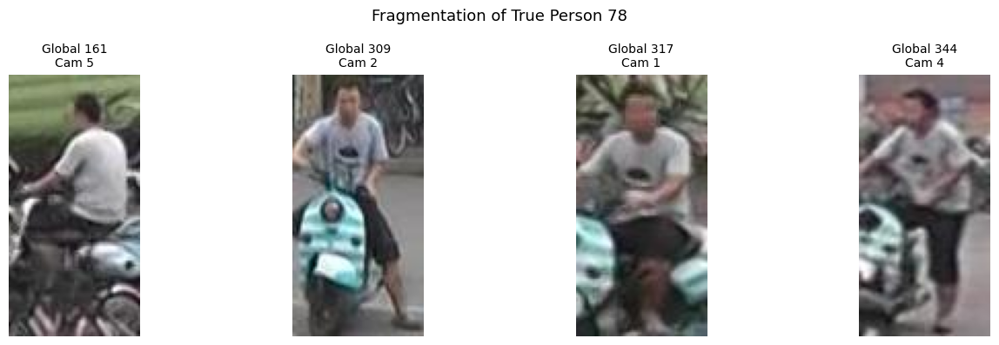


True person 262 was split into 6 Global IDs: [ 39 370  38 445 520  78]


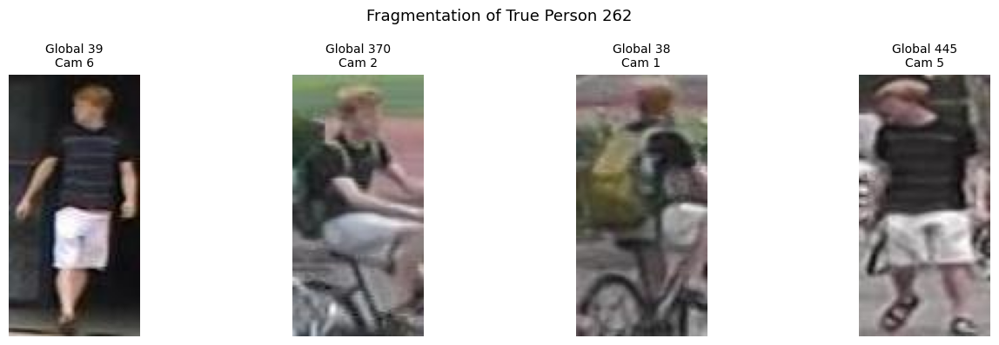


True person 226 was split into 6 Global IDs: [176 199 455 237 238   1]


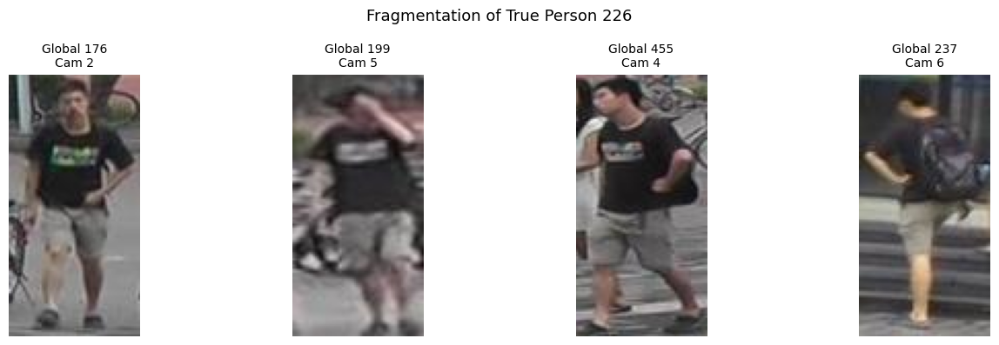


True person 109 was split into 6 Global IDs: [273  23  15  52  19 545]


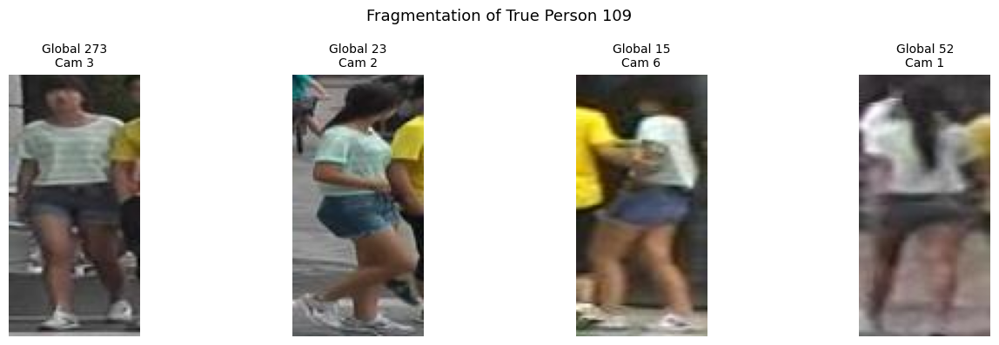

In [57]:
print("\n>>> Fragmentation examples (same true person received multiple Global IDs)")

fragmented = true_to_gids[true_to_gids > 1].sort_values(ascending=False).head()

for true_pid, n_gids in fragmented.items():
    subset = results_df[results_df.true_pid == true_pid]
    gids = subset.global_id.unique()

    print(f"\nTrue person {true_pid} was split into {n_gids} Global IDs: {gids}")

    #Show one image per Global ID
    fig, axes = plt.subplots(1, min(4, len(gids)), figsize=(3.5*min(4, len(gids)), 4))

    if len(gids) == 1:
        axes = [axes]

    for ax, gid in zip(axes, gids[:4]):
        row = subset[subset.global_id == gid].iloc[0]
        img = Image.open(query_dataset.df.iloc[row.query_idx]['path'])
        ax.imshow(img)
        ax.set_title(f"Global {gid}\nCam {row.camid}", fontsize=10)
        ax.axis('off')

    plt.suptitle(f"Fragmentation of True Person {true_pid}", fontsize=13)
    plt.tight_layout()
    plt.show()


#### Summary Dashboard

In [58]:
summary = pd.DataFrame({
    "Metric": [
        "Query images processed",
        "True unique identities",
        "Global IDs created",
        "Avg Global IDs per person",
        "Persons with single Global ID",
        "Average Global ID purity",
        "Cross-camera Rank-1",
        "Cross-camera mAP"
    ],
    "Value": [
        len(results_df),
        len(np.unique(q_pids)),
        manager.next_global_id - 1,
        f"{true_to_gids.mean():.2f}",
        f"{(true_to_gids == 1).sum()} / {len(true_to_gids)}",
        f"{gid_purity.mean()*100:.1f}%",
        f"{metrics['Rank-1']:.1f}%",
        f"{metrics['mAP']:.1f}%"
    ]
})

display(summary)

,Metric,Value
0,Query images processed,3368
1,True unique identities,750
2,Global IDs created,665
3,Avg Global IDs per person,2.55
4,Persons with single Global ID,188 / 750
5,Average Global ID purity,87.5%
6,Cross-camera Rank-1,41.1%
7,Cross-camera mAP,21.8%


### Phase 5 Complete. What it demonstrates?

1. The ReID embeddings are used to link the same person across different cameras.

2. A simple but realistic online Global ID Manager is implemented.

3. We can measure both classic ReID metrics and tracking-style metrics 
   (fragmentation rate, purity of Global IDs).

4. Visualizations clearly show successful multi-camera associations 
   and the remaining failure cases (mainly caused by large appearance changes).

This is the core technology behind frictionless retail tracking systems.

-------------------------------------------------

## Phase 6: 
### Deployment – Interactive Multi-Camera ReID Demo (Gradio)

This phase creates a clean, interactive Gradio web app that lets you:

Upload a person image (query)
Get the top matching people from the gallery (cross-camera)
See similarity scores + Global ID style results
Browse example multi-camera matches

In [ ]:
import gradio as gr

from torchvision import transforms

#Loading the model from previos phase
model = ReIDModel(num_classes=train_dataset.num_pids, embed_dim=512).to(device)
model.load_state_dict(torch.load('best_reid_model.pth',map_location=device))
model.eval()

#We already have gf, g_pids, g_camids from phase 5

@torch.no_grad()
def extract_gallery_features():
    model.eval()
    features, pids, camids, paths = [],[],[],[]

    for imgs, labels, cams in tqdm(gallery_loader, desc='Extracting gallery'):
        imgs = imgs.to(device)
        feat = model(imgs, return_feat=True)
        features.append(feat.cpu())
        pids.extend(labels.numpy())
        camids.extend(cams.numpy())

    features = torch.cat(features, dim=0)
    features = F.normalize(features, p=2, dim=1)
    return features, np.array(pids), np.array(camids)

print(f"Gallery ready: {gf.shape[0]} embeddings")


# INFERENCE TRANSFORMERS

infer_transform = transforms.Compose([
    transforms.Resize((225,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

# CORE SEARCH FUNCTION
@torch.no_grad()
def search_person(query_img, top_k=6):
    if query_img is None:
        return None, 'Please an image'

        #preprocess
        img = query_img.convert('RGB')
        tensor = infer_transform(img).unsqueeze(0).to(device)

        #Extract feature
        feat = model(tensor, return_feat=True)
        feat = F.normalize(feat, p=2, dim=1).cpu()

        #Compute similarities
        sims = torch.mm(feat, gf.t()).squeeze(0)
        topk_sim , topk_idx = torch.topk(sims, k=topk + 10)

        results = []
        used = 0
        for sim, idx in zip(topk_sim, topk_idx):
            if used >= top_k:
                break
            path = gallery_dataset.df.iloc[idx.item()]['path']
            pid = g_pids[idx.item()]
            cam = g_camids[idx.item()]

            results.append({
            "image": Image.open(path),
            "pid": int(pid),
            "camera": int(cam),
            "similarity": float(sim)
        })
            used += 1

        #Create a nice gallery output
        gallery_images = []
        captions = []
        for r in results:
            gallery_images.append(r['image'])
            captions.append(f"ID: {r['pid']} | Cam: {r['camera']} | Sim: {r['similarity']:.3f}")


        into = f'Top {top_k} matches found from {len(gf)} gallery images.'
        return gallery_images, captions, info


# EXAMPLE MULTI-CAMERA VIEWER

def show_random_multi_camera_example():
    #pick a person who appears in multiple cameras
    cam_counts = df_train.groupby('pid')['camid'].nunique()
    good_pids = cam_counts[cam_counts >=3].index.tolist()

    if not good_pids:
        return [], 'No multi-camera examples found.'

    pid = random.choice(good_pids)
    person_df = df_train[df_train.pid == pid].sort_values('camid')

    images = []
    captions = []
    for cam in sorted(person_df.camid.unqiue())[:5]:
        row = person_df[person_df.camid == cam].iloc[0]
        images.append(Image.open(row['path']))
        captions.append(f'True ID {pid} | Camera {cam}' )

    return images, captions

# NOW BUILDING GRADIO INTERFACE
with gr.Blocks(title='Frictionless Retail Tracking - Multi-Camera ReID',theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🛍️ Frictionless Retail Tracking
    ### Multi-Camera Person Re-Identification Demo
    Upload a photo of a person and the system will find the same person across different cameras.
    """)

    with gr.Tab('Search Person (Cross-Camera)'):
        with gr.Row():
            with gr.Column(scale=1):
                query_input = gr.Image(type='pil', label='Upload Query Image')
                topk_slider = gr.Slider(3,10,value=6, step=1, label='Top-K Matches')
                search_btn = gr.Button('Search Across Cameras', variant='primary')

            with gr.Column(scale=2):
                output_gallery = gr.Gallery(label='Top Matches', columns=3, height=400)
                output_info = gr.Textbox(label='Status', interactive=False)


        search_btn.click(
            fn=search_person,
            inputs = [query_input, topk_slider],
            outputs = [output_gallery, output_info] 
        )

    with gr.Tab('Multi-Camera Examples'):
        gr.Markdown('See how the same person looks from different cameras (the core challenge of ReID)')
        example_btn = gr.Button('Show Random Multi-Camera Example')
        example_gallery = gr.Gallery(label='Same Person - Different Cameras', columns=5, height=350)

        example_btn.click(
            fn=show_random_multi_camera_example,
            outputs=[example_gallery]
        )
    
    with gr.Tab("ℹ️ About"):
            gr.Markdown("""
            ### System Overview
            - **Detection**: YOLO (planned for full video version)
            - **Single-camera Tracking**: ByteTrack / DeepSORT
            - **Re-Identification**: ResNet-50 + Triplet + Cross-Entropy
            - **Multi-camera Association**: Embedding similarity + Global ID Manager
            
            This demo currently uses the Market-1501 dataset (6 cameras).  
            After retraining with more epochs the matching quality will improve significantly.
            
            **Next real-world step**: Replace the static gallery with live camera streams.
            """)




print('Launching Gradio demo..')
demo.launch(share=True, debug=True)

Gallery ready: 15913 embeddings
Launching Gradio demo..
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b1b2752d505266662c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
